# XQuality cumulative prefix consolidation evaluation

This notebook implements the stronger diagnostic we discussed:

> **Stopping after Layer k means using all prefix outputs from Layers 0..k**, then merging equivalent triples and filtering them into a compact KG, instead of evaluating each prefix output independently.

This makes the experiment closer to NeoOLAF's real logic:

- later layers do not replace earlier evidence;
- later layers add evidence;
- equivalent triples are merged;
- noisy triples are filtered;
- all stop points are compared with the same KG budget, usually the size of the native final export.

The native NeoOLAF final export is still shown as a separate reference point.


## 1. Configuration

In [1]:
from pathlib import Path
import sys
import json
import math
import pandas as pd
import numpy as np

def find_project_root(start=None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src" / "neoolaf").exists():
            return p
    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "examples" / "XQualityMachine32").exists():
            return p
    raise RuntimeError("Could not find NeoOLAF project root. Start Jupyter inside the NeoOLAF repository.")

PROJECT_ROOT = find_project_root()
EXAMPLE_ROOT = PROJECT_ROOT / "examples" / "XQualityMachine32"
RUNS_ROOT = EXAMPLE_ROOT / "runs"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PREFIX_RUNS_DIR = RUNS_ROOT / "prefix_stop_after_layer_llm_finalization_exact_eval"
GOLD_PATH = PROJECT_ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"

# If None, the notebook auto-detects the likely native NeoOLAF final export.
FINAL_EXPORT_DIR = None

OUTPUT_DIR = RUNS_ROOT / "cumulative_prefix_consolidation_eval"

PROFILE = "xquality_relaxed_recall"

# Important:
# None means "use the native final export triple count as budget".
# If no final export is detected, the fallback budget below is used.
KG_BUDGET = None
FALLBACK_KG_BUDGET = 226

# Merge threshold for cumulative consolidation.
# Higher = stricter merging. Reasonable range: 0.82--0.90.
SIMILARITY_THRESHOLD = 0.86

# Leave None unless you want to discard very weak clusters.
MIN_CLUSTER_SCORE = None

STRICT_COMPLETED_MARKER = False
MIN_TRIPLES = 1

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("CWD:", Path.cwd().resolve())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREFIX_RUNS_DIR:", PREFIX_RUNS_DIR)
print("GOLD_PATH:", GOLD_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not PREFIX_RUNS_DIR.exists():
    raise FileNotFoundError(f"PREFIX_RUNS_DIR does not exist: {PREFIX_RUNS_DIR}")
if not GOLD_PATH.exists():
    raise FileNotFoundError(f"GOLD_PATH does not exist: {GOLD_PATH}")

CWD: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32
PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
PREFIX_RUNS_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval
GOLD_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Examples\XQuality_all_triplets_flat_en.json
OUTPUT_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval


## 2. Import the cumulative evaluator

If this fails, copy the patch files into your repository first.

In [2]:
from neoolaf.evaluation.runners.evaluate_ablation_robust import (
    discover_prefix_folders,
    load_triples_any,
)
from neoolaf.evaluation.runners.evaluate_cumulative_prefix_consolidation import (
    evaluate_cumulative_prefix_consolidation,
)

print("Cumulative consolidation evaluator imported successfully.")

Cumulative consolidation evaluator imported successfully.


## 3. Discover prefix folders and auto-detect native final export

In [3]:
prefix_folders = discover_prefix_folders(
    PREFIX_RUNS_DIR,
    min_triples=MIN_TRIPLES,
    strict_completed_marker=STRICT_COMPLETED_MARKER,
)

print(f"Discovered {len(prefix_folders)} prefix folders.")
display(pd.DataFrame([
    {
        "stop_index": x["stop_index"],
        "layer_name": x["layer_name"],
        "triple_count": x["triple_count"],
        "folder": str(x["folder"]),
    }
    for x in prefix_folders
]))

def count_triples_in_folder(folder: Path) -> int:
    triples, _ = load_triples_any(folder)
    return len(triples)

def find_candidate_final_export_dirs(project_root: Path, prefix_runs_dir: Path, output_dir: Path):
    candidates = []
    search_root = project_root / "examples" / "XQualityMachine32" / "runs"
    if not search_root.exists():
        return candidates

    prefix_resolved = prefix_runs_dir.resolve()
    output_resolved = output_dir.resolve()

    for kg_file in list(search_root.glob("**/kg_inferred.json")) + list(search_root.glob("**/kg_local.json")) + list(search_root.glob("**/kg.json")):
        folder = kg_file.parent
        try:
            folder_resolved = folder.resolve()
            if str(folder_resolved).startswith(str(prefix_resolved)):
                continue
            if str(folder_resolved).startswith(str(output_resolved)):
                continue
            if "cumulative_prefix_consolidation_eval" in str(folder_resolved):
                continue
            if "prefix_stop_after_layer_robust_eval" in str(folder_resolved):
                continue
        except Exception:
            pass

        try:
            triple_count = count_triples_in_folder(folder)
        except Exception:
            triple_count = 0
        if triple_count <= 0:
            continue

        candidates.append({
            "folder": folder,
            "triple_count": triple_count,
            "mtime": kg_file.stat().st_mtime,
            "kg_file": kg_file,
        })

    # Prefer the known 226-triple export, then newest.
    candidates.sort(key=lambda x: (x["triple_count"] == 226, x["mtime"]), reverse=True)
    return candidates

if FINAL_EXPORT_DIR is None:
    candidates = find_candidate_final_export_dirs(PROJECT_ROOT, PREFIX_RUNS_DIR, OUTPUT_DIR)
    print(f"Found {len(candidates)} candidate final export folders.")
    for c in candidates[:10]:
        print(c["triple_count"], "|", c["folder"])
    FINAL_EXPORT_DIR = candidates[0]["folder"] if candidates else None

print("Selected FINAL_EXPORT_DIR:", FINAL_EXPORT_DIR)

if FINAL_EXPORT_DIR is not None:
    final_triple_count = count_triples_in_folder(Path(FINAL_EXPORT_DIR))
    print("Native final export triple count:", final_triple_count)
else:
    final_triple_count = None
    print("WARNING: No native final export selected. The notebook will still run, but without final reference.")

Discovered 13 prefix folders.


,stop_index,layer_name,triple_count,folder
0,0,prefix_stop_after_00_layer00_preprocessing,124,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
1,1,prefix_stop_after_01_layer01_linguistic_expres...,841,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
2,2,prefix_stop_after_02_layer02_candidate_enrichment,1428,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
3,3,prefix_stop_after_03_layer03_candidate_typing_...,1812,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
4,4,prefix_stop_after_04_layer04_candidate_relatio...,2669,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
5,5,prefix_stop_after_05_layer05_candidate_triple_...,2657,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
6,6,prefix_stop_after_06_layer06_concept_relation_...,2742,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
7,7,prefix_stop_after_07_layer07_hierarchisation,2642,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
8,8,prefix_stop_after_08_layer08_axiom_schemata_ex...,2881,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
9,9,prefix_stop_after_09_layer09_general_axiom_ext...,3121,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...


Found 29 candidate final export folders.
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\sure_resume_from_layer02_parallel_20260702_151953\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\sure_resume_from_layer02_parallel_20260702_151953\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer03_from_l2\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer03_from_l2\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer12_from_l11\exports
226 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\layer12_from_l11\exports
11 | C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\normalized_inp

## 4. Choose a fixed KG budget

A fixed budget makes the stop-layer outputs comparable. By default we use the native final export size.

In [4]:
if KG_BUDGET is None:
    KG_BUDGET_EFFECTIVE = int(final_triple_count) if final_triple_count else FALLBACK_KG_BUDGET
else:
    KG_BUDGET_EFFECTIVE = int(KG_BUDGET)

print("KG_BUDGET_EFFECTIVE:", KG_BUDGET_EFFECTIVE)
print("This means every cumulative stop-layer KG will keep at most this many consolidated triples.")

KG_BUDGET_EFFECTIVE: 226
This means every cumulative stop-layer KG will keep at most this many consolidated triples.


## 5. Run cumulative consolidation + exact robust evaluation

In [5]:
result = evaluate_cumulative_prefix_consolidation(
    prefix_runs_dir=PREFIX_RUNS_DIR,
    gold_path=GOLD_PATH,
    output_dir=OUTPUT_DIR,
    profile=PROFILE,
    final_export_dir=FINAL_EXPORT_DIR,
    budget=KG_BUDGET_EFFECTIVE,
    similarity_threshold=SIMILARITY_THRESHOLD,
    min_score=MIN_CLUSTER_SCORE,
    min_triples=MIN_TRIPLES,
    strict_completed_marker=STRICT_COMPLETED_MARKER,
    make_plots=True,
)

summary_df = result["summary_df"].copy()
per_relation_df = result["per_relation_df"].copy()
errors = result["errors"]

print("Summary CSV:", result["summary_csv"])
print("Per-relation CSV:", result["per_relation_csv"])
print("Errors:", len(errors))
if errors:
    display(pd.DataFrame(errors))

display(summary_df)

Summary CSV: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_consolidated_robust_summary.csv
Per-relation CSV: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_consolidated_robust_per_relation.csv
Errors: 0


,series,layer_name,stop_index,profile,raw_triple_count,usable_triple_count,triple_count,source_folder,normalized_input_folder,pred_relations_seen_by_evaluator,...,gold_miss_rate,triples_per_gold_relation,matched_relations_per_100_triples,candidate_cluster_count,selected_cluster_count,avg_cluster_score,avg_support_count,avg_support_layers,max_support_layers,source_prefix_folder
0,cumulative_consolidated_prefix_output,cumulative_stop_after_00_prefix_stop_after_00_...,0,xquality_relaxed_recall,55,55,55,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,4,...,0.990888,0.125285,7.272727,55.0,55.0,4.425284,2.254545,1.000000,1.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
1,cumulative_consolidated_prefix_output,cumulative_stop_after_01_prefix_stop_after_01_...,1,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,102,...,0.767654,0.514806,45.132743,542.0,226.0,3.731654,2.871681,1.194690,2.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
2,cumulative_consolidated_prefix_output,cumulative_stop_after_02_prefix_stop_after_02_...,2,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,105,...,0.760820,0.514806,46.460177,1108.0,226.0,4.495523,5.079646,2.150442,3.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
3,cumulative_consolidated_prefix_output,cumulative_stop_after_03_prefix_stop_after_03_...,3,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,112,...,0.744875,0.514806,49.557522,1656.0,226.0,5.033534,7.619469,3.101770,4.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
4,cumulative_consolidated_prefix_output,cumulative_stop_after_04_prefix_stop_after_04_...,4,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,107,...,0.756264,0.514806,47.345133,2295.0,226.0,5.476479,11.238938,3.973451,5.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
5,cumulative_consolidated_prefix_output,cumulative_stop_after_05_prefix_stop_after_05_...,5,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,110,...,0.749431,0.514806,48.672566,2683.0,226.0,5.832726,14.915929,4.955752,6.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
6,cumulative_consolidated_prefix_output,cumulative_stop_after_06_prefix_stop_after_06_...,6,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,97,...,0.779043,0.514806,42.920354,3013.0,226.0,6.112722,18.676991,5.862832,7.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
7,cumulative_consolidated_prefix_output,cumulative_stop_after_07_prefix_stop_after_07_...,7,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,95,...,0.783599,0.514806,42.035398,3330.0,226.0,6.340161,22.557522,6.765487,8.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
8,cumulative_consolidated_prefix_output,cumulative_stop_after_08_prefix_stop_after_08_...,8,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,86,...,0.804100,0.514806,38.053097,3687.0,226.0,6.548034,26.446903,7.769912,9.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...
9,cumulative_consolidated_prefix_output,cumulative_stop_after_09_prefix_stop_after_09_...,9,xquality_relaxed_recall,226,226,226,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,87,...,0.801822,0.514806,38.495575,3981.0,226.0,6.719538,30.340708,8.730088,10.0,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...


## 6. Add efficiency-weighted metrics

In [6]:
def fbeta(precision_like, recall_like, beta=1.0):
    p = float(precision_like) if pd.notna(precision_like) else 0.0
    r = float(recall_like) if pd.notna(recall_like) else 0.0
    if p <= 0 or r <= 0:
        return 0.0
    b2 = beta ** 2
    return (1 + b2) * p * r / ((b2 * p) + r)

def harmonic2(a, b):
    a = float(a) if pd.notna(a) else 0.0
    b = float(b) if pd.notna(b) else 0.0
    if a <= 0 or b <= 0:
        return 0.0
    return 2 * a * b / (a + b)

summary_df["coverage_efficiency_f05"] = summary_df.apply(
    lambda r: fbeta(
        r.get("raw_output_efficiency", 0.0),
        r.get("gold_relation_coverage", 0.0),
        beta=0.5,
    ),
    axis=1,
)

summary_df["entity_adjusted_ce_f05"] = summary_df.apply(
    lambda r: harmonic2(
        r.get("coverage_efficiency_f05", 0.0),
        r.get("entity_f1", 0.0),
    ),
    axis=1,
)

# Save updated table.
summary_df.to_csv(OUTPUT_DIR / "cumulative_consolidated_robust_summary_with_f05.csv", index=False)

main_cols = [
    "series",
    "layer_name",
    "stop_index",
    "raw_triple_count",
    "relation_tp",
    "gold_relation_count",
    "gold_relation_coverage",
    "raw_output_efficiency",
    "coverage_efficiency_f1",
    "coverage_efficiency_f05",
    "entity_f1",
    "entity_relation_balanced_f1",
    "entity_adjusted_ce_f05",
    "overgeneration_factor",
    "candidate_cluster_count",
    "selected_cluster_count",
    "avg_support_layers",
    "relation_f1",
]
main_cols = [c for c in main_cols if c in summary_df.columns]

display(summary_df[main_cols].sort_values(["series", "stop_index"]))

,series,layer_name,stop_index,raw_triple_count,relation_tp,gold_relation_count,gold_relation_coverage,raw_output_efficiency,coverage_efficiency_f1,coverage_efficiency_f05,entity_f1,entity_relation_balanced_f1,entity_adjusted_ce_f05,overgeneration_factor,candidate_cluster_count,selected_cluster_count,avg_support_layers,relation_f1
0,cumulative_consolidated_prefix_output,cumulative_stop_after_00_prefix_stop_after_00_...,0,55,4,439,0.009112,0.072727,0.016194,0.030349,0.037534,0.022626,0.033561,13.750000,55.0,55.0,1.000000,0.018059
1,cumulative_consolidated_prefix_output,cumulative_stop_after_01_prefix_stop_after_01_...,1,226,102,439,0.232346,0.451327,0.306767,0.379747,0.252836,0.277203,0.303561,2.215686,542.0,226.0,1.194690,0.377079
2,cumulative_consolidated_prefix_output,cumulative_stop_after_02_prefix_stop_after_02_...,2,226,105,439,0.239180,0.464602,0.315789,0.390916,0.263492,0.287280,0.314798,2.152381,1108.0,226.0,2.150442,0.386029
3,cumulative_consolidated_prefix_output,cumulative_stop_after_03_prefix_stop_after_03_...,3,226,112,439,0.255125,0.495575,0.336842,0.416977,0.279874,0.305727,0.334938,2.017857,1656.0,226.0,3.101770,0.406534
4,cumulative_consolidated_prefix_output,cumulative_stop_after_04_prefix_stop_after_04_...,4,226,107,439,0.243736,0.473451,0.321805,0.398362,0.295322,0.307995,0.339189,2.112150,2295.0,226.0,3.973451,0.391941
5,cumulative_consolidated_prefix_output,cumulative_stop_after_05_prefix_stop_after_05_...,5,226,110,439,0.250569,0.486726,0.330827,0.409531,0.303207,0.316415,0.348438,2.054545,2683.0,226.0,4.955752,0.400729
6,cumulative_consolidated_prefix_output,cumulative_stop_after_06_prefix_stop_after_06_...,6,226,97,439,0.220957,0.429204,0.291729,0.361132,0.275037,0.283138,0.312259,2.329897,3013.0,226.0,5.862832,0.361940
7,cumulative_consolidated_prefix_output,cumulative_stop_after_07_prefix_stop_after_07_...,7,226,95,439,0.216401,0.420354,0.285714,0.353686,0.266462,0.275753,0.303940,2.378947,3330.0,226.0,6.765487,0.355805
8,cumulative_consolidated_prefix_output,cumulative_stop_after_08_prefix_stop_after_08_...,8,226,86,439,0.195900,0.380531,0.258647,0.320179,0.261538,0.260085,0.287903,2.627907,3687.0,226.0,7.769912,0.327619
9,cumulative_consolidated_prefix_output,cumulative_stop_after_09_prefix_stop_after_09_...,9,226,87,439,0.198178,0.384956,0.261654,0.323902,0.268105,0.264840,0.293374,2.597701,3981.0,226.0,8.730088,0.330798


## 7. Plot cumulative consolidated curve with native final export

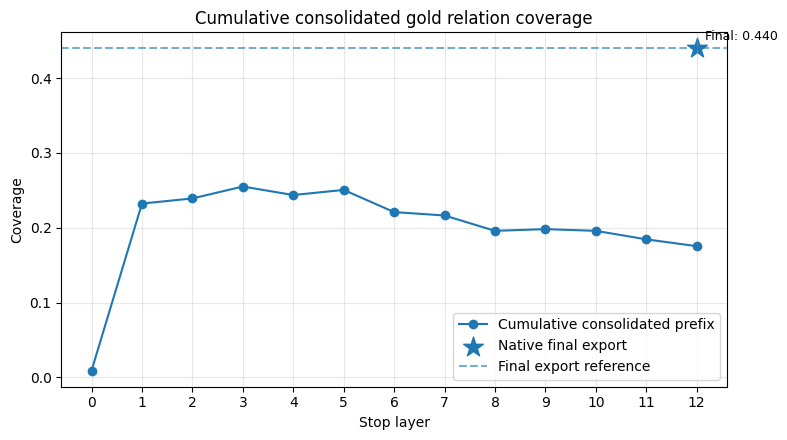

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_plot_gold_relation_coverage.png


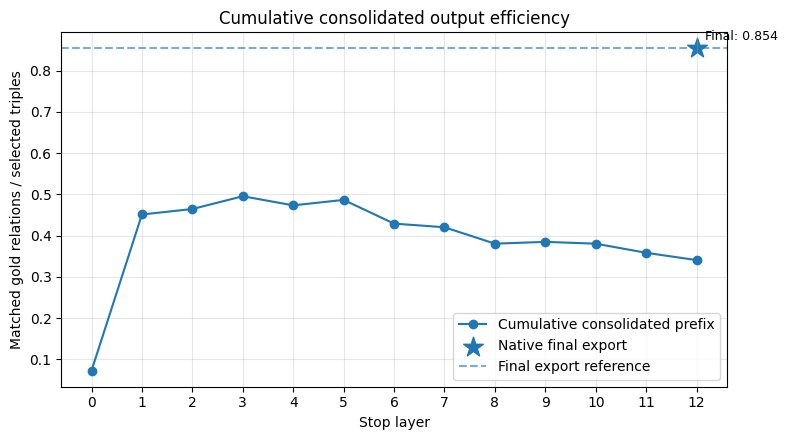

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_plot_raw_output_efficiency.png


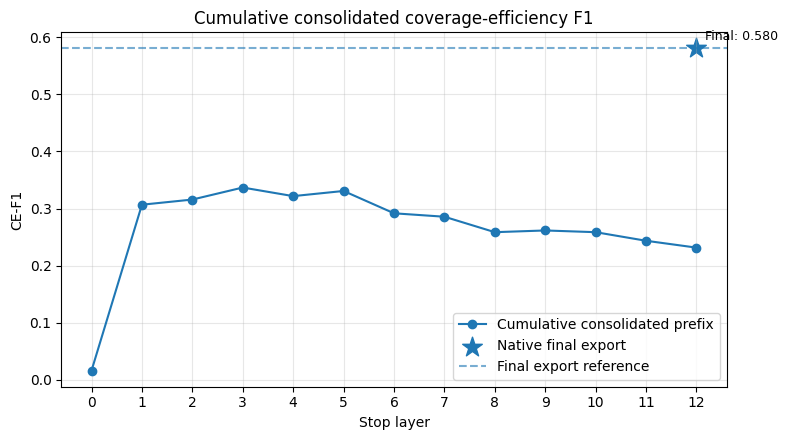

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_plot_coverage_efficiency_f1.png


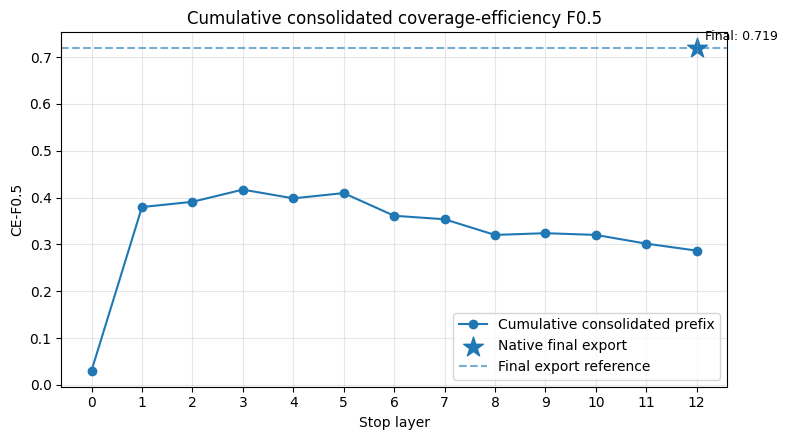

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_plot_coverage_efficiency_f05.png


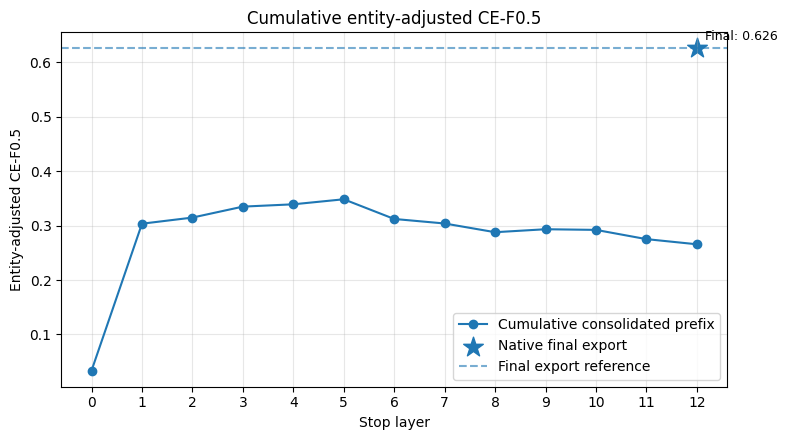

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_plot_entity_adjusted_ce_f05.png


In [7]:
import matplotlib.pyplot as plt

plot_df = summary_df[
    summary_df["series"] == "cumulative_consolidated_prefix_output"
].copy()
plot_df = plot_df[plot_df["stop_index"].notna()].sort_values("stop_index")

final_row = None
final_df = summary_df[summary_df["series"] == "native_neoolaf_final_export"].copy()
if len(final_df):
    final_row = final_df.iloc[0]

def plot_metric(metric, title, ylabel):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        plot_df["stop_index"],
        plot_df[metric],
        marker="o",
        label="Cumulative consolidated prefix"
    )

    if final_row is not None and metric in final_row.index and pd.notna(final_row[metric]):
        final_y = final_row[metric]
        ax.scatter([12], [final_y], marker="*", s=220, label="Native final export")
        ax.axhline(final_y, linestyle="--", alpha=0.6, label="Final export reference")
        ax.annotate(
            f"Final: {final_y:.3f}",
            xy=(12, final_y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_xlabel("Stop layer")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(set(plot_df["stop_index"].dropna().astype(int).tolist() + [12])))
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    out_path = OUTPUT_DIR / f"cumulative_plot_{metric}.png"
    fig.savefig(out_path, dpi=180)
    plt.show()
    print("Saved:", out_path)

for metric, title, ylabel in [
    ("gold_relation_coverage", "Cumulative consolidated gold relation coverage", "Coverage"),
    ("raw_output_efficiency", "Cumulative consolidated output efficiency", "Matched gold relations / selected triples"),
    ("coverage_efficiency_f1", "Cumulative consolidated coverage-efficiency F1", "CE-F1"),
    ("coverage_efficiency_f05", "Cumulative consolidated coverage-efficiency F0.5", "CE-F0.5"),
    ("entity_adjusted_ce_f05", "Cumulative entity-adjusted CE-F0.5", "Entity-adjusted CE-F0.5"),
]:
    if metric in summary_df.columns:
        plot_metric(metric, title, ylabel)

## 8. Pareto plot: coverage vs efficiency

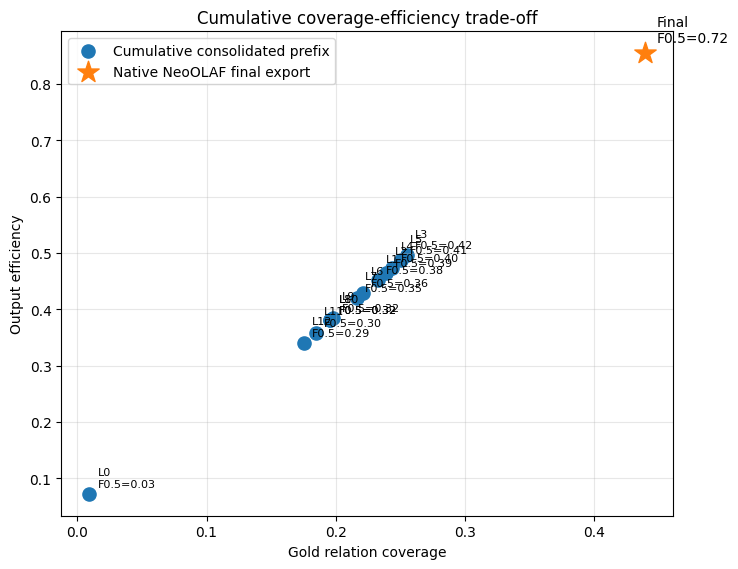

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\cumulative_prefix_consolidation_eval\cumulative_pareto_coverage_efficiency_f05.png


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.8))

ax.scatter(
    plot_df["gold_relation_coverage"],
    plot_df["raw_output_efficiency"],
    s=90,
    label="Cumulative consolidated prefix"
)

for _, row in plot_df.iterrows():
    label = f"L{int(row['stop_index'])}"
    if "coverage_efficiency_f05" in row:
        label += f"\nF0.5={row['coverage_efficiency_f05']:.2f}"
    ax.annotate(
        label,
        xy=(row["gold_relation_coverage"], row["raw_output_efficiency"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )

if final_row is not None:
    ax.scatter(
        [final_row["gold_relation_coverage"]],
        [final_row["raw_output_efficiency"]],
        marker="*",
        s=260,
        label="Native NeoOLAF final export",
    )
    ax.annotate(
        f"Final\nF0.5={final_row.get('coverage_efficiency_f05', float('nan')):.2f}",
        xy=(final_row["gold_relation_coverage"], final_row["raw_output_efficiency"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_title("Cumulative coverage-efficiency trade-off")
ax.set_xlabel("Gold relation coverage")
ax.set_ylabel("Output efficiency")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

out_path = OUTPUT_DIR / "cumulative_pareto_coverage_efficiency_f05.png"
fig.savefig(out_path, dpi=180)
plt.show()
print("Saved:", out_path)

## 9. Marginal layer changes

This is not an oracle set-difference of gold relation IDs, but it shows observed aggregate changes after each new cumulative prefix layer.

In [9]:
delta_df = plot_df.copy()

for col in [
    "relation_tp",
    "raw_triple_count",
    "gold_relation_coverage",
    "raw_output_efficiency",
    "coverage_efficiency_f1",
    "coverage_efficiency_f05",
    "entity_f1",
    "entity_adjusted_ce_f05",
    "candidate_cluster_count",
    "selected_cluster_count",
    "avg_support_layers",
]:
    if col in delta_df.columns:
        delta_df[f"delta_{col}"] = delta_df[col].diff()

if "delta_relation_tp" in delta_df.columns and "delta_raw_triple_count" in delta_df.columns:
    delta_df["marginal_tp_per_selected_triple_change"] = delta_df.apply(
        lambda r: (
            r["delta_relation_tp"] / r["delta_raw_triple_count"]
            if pd.notna(r["delta_raw_triple_count"]) and r["delta_raw_triple_count"] != 0
            else np.nan
        ),
        axis=1,
    )

delta_cols = [
    "stop_index",
    "layer_name",
    "relation_tp",
    "delta_relation_tp",
    "raw_triple_count",
    "delta_raw_triple_count",
    "gold_relation_coverage",
    "delta_gold_relation_coverage",
    "raw_output_efficiency",
    "delta_raw_output_efficiency",
    "coverage_efficiency_f05",
    "delta_coverage_efficiency_f05",
    "entity_adjusted_ce_f05",
    "delta_entity_adjusted_ce_f05",
    "candidate_cluster_count",
    "delta_candidate_cluster_count",
    "avg_support_layers",
    "delta_avg_support_layers",
]
delta_cols = [c for c in delta_cols if c in delta_df.columns]

delta_df[delta_cols].to_csv(OUTPUT_DIR / "cumulative_marginal_layer_changes.csv", index=False)
display(delta_df[delta_cols])

,stop_index,layer_name,relation_tp,delta_relation_tp,raw_triple_count,delta_raw_triple_count,gold_relation_coverage,delta_gold_relation_coverage,raw_output_efficiency,delta_raw_output_efficiency,coverage_efficiency_f05,delta_coverage_efficiency_f05,entity_adjusted_ce_f05,delta_entity_adjusted_ce_f05,candidate_cluster_count,delta_candidate_cluster_count,avg_support_layers,delta_avg_support_layers
0,0,cumulative_stop_after_00_prefix_stop_after_00_...,4,NaN,55,NaN,0.009112,NaN,0.072727,NaN,0.030349,NaN,0.033561,NaN,55.0,NaN,1.000000,NaN
1,1,cumulative_stop_after_01_prefix_stop_after_01_...,102,98.0,226,171.0,0.232346,0.223235,0.451327,0.378600,0.379747,0.349398,0.303561,0.270000,542.0,487.0,1.194690,0.194690
2,2,cumulative_stop_after_02_prefix_stop_after_02_...,105,3.0,226,0.0,0.239180,0.006834,0.464602,0.013274,0.390916,0.011169,0.314798,0.011237,1108.0,566.0,2.150442,0.955752
3,3,cumulative_stop_after_03_prefix_stop_after_03_...,112,7.0,226,0.0,0.255125,0.015945,0.495575,0.030973,0.416977,0.026061,0.334938,0.020140,1656.0,548.0,3.101770,0.951327
4,4,cumulative_stop_after_04_prefix_stop_after_04_...,107,-5.0,226,0.0,0.243736,-0.011390,0.473451,-0.022124,0.398362,-0.018615,0.339189,0.004251,2295.0,639.0,3.973451,0.871681
5,5,cumulative_stop_after_05_prefix_stop_after_05_...,110,3.0,226,0.0,0.250569,0.006834,0.486726,0.013274,0.409531,0.011169,0.348438,0.009250,2683.0,388.0,4.955752,0.982301
6,6,cumulative_stop_after_06_prefix_stop_after_06_...,97,-13.0,226,0.0,0.220957,-0.029613,0.429204,-0.057522,0.361132,-0.048399,0.312259,-0.036180,3013.0,330.0,5.862832,0.907080
7,7,cumulative_stop_after_07_prefix_stop_after_07_...,95,-2.0,226,0.0,0.216401,-0.004556,0.420354,-0.008850,0.353686,-0.007446,0.303940,-0.008319,3330.0,317.0,6.765487,0.902655
8,8,cumulative_stop_after_08_prefix_stop_after_08_...,86,-9.0,226,0.0,0.195900,-0.020501,0.380531,-0.039823,0.320179,-0.033507,0.287903,-0.016037,3687.0,357.0,7.769912,1.004425
9,9,cumulative_stop_after_09_prefix_stop_after_09_...,87,1.0,226,0.0,0.198178,0.002278,0.384956,0.004425,0.323902,0.003723,0.293374,0.005471,3981.0,294.0,8.730088,0.960177


## 10. Finalization gain table

This compares the native final export to the cumulative consolidated Layer 12 output, using the same robust metrics.

In [10]:
if final_row is not None and 12 in set(plot_df["stop_index"]):
    ref = plot_df[plot_df["stop_index"] == 12].iloc[0]

    def safe_ratio(a, b):
        if pd.isna(a) or pd.isna(b) or float(b) == 0:
            return np.nan
        return float(a) / float(b)

    finalization_gain = pd.DataFrame([{
        "comparison": "Native final export vs cumulative consolidated Layer 12 prefix",
        "reference_layer": ref["layer_name"],
        "raw_triple_count_reference": ref["raw_triple_count"],
        "raw_triple_count_final": final_row["raw_triple_count"],
        "relation_tp_reference": ref["relation_tp"],
        "relation_tp_final": final_row["relation_tp"],
        "coverage_reference": ref["gold_relation_coverage"],
        "coverage_final": final_row["gold_relation_coverage"],
        "coverage_delta_final_minus_reference": final_row["gold_relation_coverage"] - ref["gold_relation_coverage"],
        "efficiency_reference": ref["raw_output_efficiency"],
        "efficiency_final": final_row["raw_output_efficiency"],
        "efficiency_gain_factor": safe_ratio(final_row["raw_output_efficiency"], ref["raw_output_efficiency"]),
        "entity_f1_reference": ref["entity_f1"],
        "entity_f1_final": final_row["entity_f1"],
        "entity_f1_delta": final_row["entity_f1"] - ref["entity_f1"],
        "ce_f05_reference": ref["coverage_efficiency_f05"],
        "ce_f05_final": final_row["coverage_efficiency_f05"],
        "ce_f05_delta": final_row["coverage_efficiency_f05"] - ref["coverage_efficiency_f05"],
        "entity_adjusted_ce_f05_reference": ref["entity_adjusted_ce_f05"],
        "entity_adjusted_ce_f05_final": final_row["entity_adjusted_ce_f05"],
        "entity_adjusted_ce_f05_delta": final_row["entity_adjusted_ce_f05"] - ref["entity_adjusted_ce_f05"],
    }])

    finalization_gain.to_csv(OUTPUT_DIR / "cumulative_finalization_gain_table.csv", index=False)
    display(finalization_gain.T)
else:
    print("Cannot compute finalization gain table: missing native final export or cumulative Layer 12 row.")

,0
comparison,Native final export vs cumulative consolidated...
reference_layer,cumulative_stop_after_12_prefix_stop_after_12_...
raw_triple_count_reference,226
raw_triple_count_final,226
relation_tp_reference,77
relation_tp_final,193
coverage_reference,0.175399
coverage_final,0.439636
coverage_delta_final_minus_reference,0.264237
efficiency_reference,0.340708


## 11. Recommended interpretation

Use this notebook as a **cumulative consolidation diagnostic**:

- if the cumulative curve improves, you can say later layers add useful evidence for consolidation;
- if the native final export still wins, you can say the real NeoOLAF finalization/serialization performs additional filtering/normalization beyond what the generic consolidation can reproduce;
- if Layer 12 cumulative is worse than the native final export, that is expected: the cumulative curve is a reconstructed diagnostic KG, while the star is the real NeoOLAF export.

The most important difference from the previous notebook is that the blue curve is now cumulative: Layer 12 uses all candidate information from Layers 0..12, not only the independent Layer 12 prefix output.
